In [6]:
import numpy as np
import matplotlib.pyplot as plt

def least_squares_line(x, y):
    # Returns slope m and intercept c for y = mx + c using least squares
    A = np.vstack([x, np.ones(len(x))]).T              # Build the design matrix [x  1] for the linear model
    m, c = np.linalg.lstsq(A, y, rcond=None)[0]        # Solve the least-squares problem to get slope and intercept
    return m, c

def polynomial_fit(x, y, degree):
    # Returns a NumPy polynomial object for the best-fit polynomial of the chosen degree
    coeffs = np.polyfit(x, y, degree)                  # Compute best-fit polynomial coefficients
    p = np.poly1d(coeffs)                              # Turn coefficients into a callable polynomial
    return p

def vandermonde_fit(x, y, degree):
    # Returns a polynomial fit using an explicit Vandermonde matrix and least squares
    V = np.vander(x, degree + 1)                       # Build the Vandermonde matrix [x^n ... x^1 x^0]
    coeffs = np.linalg.lstsq(V, y, rcond=None)[0]      # Solve the least-squares problem for the polynomial coefficients
    p = np.poly1d(coeffs)                              # Turn coefficients into a callable polynomial
    return p

def mse(y, yhat):
    # Compute mean squared error between actual data and predicted data
    return np.mean((y - yhat) ** 2)

def r2_score(y, yhat):
    # Compute R^2 to measure how well the model explains the variation in the data
    ss_res = np.sum((y - yhat) ** 2)                   # Residual sum of squares: unexplained variation
    ss_tot = np.sum((y - np.mean(y)) ** 2)             # Total sum of squares: total variation in y
    return 1 - ss_res / ss_tot                         # R^2 compares unexplained variation to total variation

def poly_to_string(p):
    # Convert a poly1d object into a cleaner one-line equation string
    coeffs = p.c                                       # Extract polynomial coefficients
    degree = len(coeffs) - 1                           # Highest power of x
    terms = []                                         # Store each formatted term

    for i, a in enumerate(coeffs):
        power = degree - i                             # Current power of x

        if abs(a) < 1e-12:
            continue                                   # Skip coefficients that are essentially zero

        if power > 1:
            terms.append(f"{a:.4f}x^{power}")          # Format terms like ax^n
        elif power == 1:
            terms.append(f"{a:.4f}x")                  # Format terms like ax
        else:
            terms.append(f"{a:.4f}")                   # Constant term

    eq = " + ".join(terms)                             # Join terms with plus signs
    eq = eq.replace("+ -", "- ")                       # Clean up signs like "+ -3.2x"
    return eq


# Original data from the earlier least-squares challenge

X = np.array([1, 2, 3, 4, 5], dtype=float)             # Original x data points
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1], dtype=float)   # Original y data points

x_plot = np.linspace(np.min(X), np.max(X), 400)        # Dense x values so plotted curves look smooth

Part A: Linear Least Squares vs Cubic Polynomial Fit
Line fit: y = 0.9500x + 0.5900
Line metrics: MSE = 0.061400, R^2 = 0.967102
Cubic polynomial: y = 0.0417x^3 - 0.5107x^2 + 2.7476x - 1.0600
Cubic metrics: MSE = 0.004829, R^2 = 0.997413
Better fit in Part A: Cubic polynomial fit


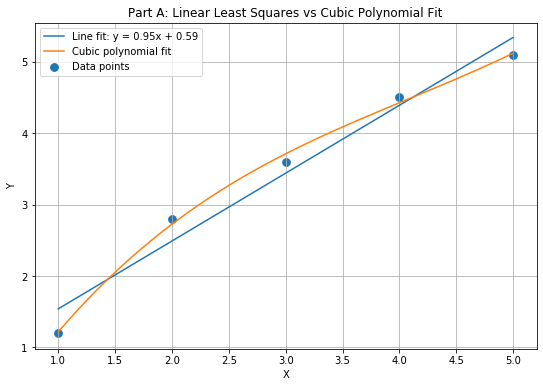

In [7]:
# Part A: Linear Least Squares vs Cubic Polynomial Fit

m_line, c_line = least_squares_line(X, Y)              # Compute the best-fit line parameters
Yhat_line = m_line * X + c_line                        # Predicted y values at the original x points
y_plot_line = m_line * x_plot + c_line                 # Predicted y values on dense x values for plotting

degree_A = 3                                           # Start with a cubic polynomial
poly3 = polynomial_fit(X, Y, degree_A)                 # Compute the cubic best-fit polynomial
Yhat_poly3 = poly3(X)                                  # Predicted y values at the original x points
y_plot_poly3 = poly3(x_plot)                           # Predicted y values on dense x values for plotting

mse_line = mse(Y, Yhat_line)                           # Mean squared error for the line
r2_line = r2_score(Y, Yhat_line)                       # R^2 value for the line

mse_poly3 = mse(Y, Yhat_poly3)                         # Mean squared error for the cubic polynomial
r2_poly3 = r2_score(Y, Yhat_poly3)                     # R^2 value for the cubic polynomial

print("Part A: Linear Least Squares vs Cubic Polynomial Fit")
print(f"Line fit: y = {m_line:.4f}x + {c_line:.4f}")
print(f"Line metrics: MSE = {mse_line:.6f}, R^2 = {r2_line:.6f}")
print(f"Cubic polynomial: y = {poly_to_string(poly3)}")
print(f"Cubic metrics: MSE = {mse_poly3:.6f}, R^2 = {r2_poly3:.6f}")

if mse_poly3 < mse_line and r2_poly3 > r2_line:
    print("Better fit in Part A: Cubic polynomial fit")
elif mse_line < mse_poly3 and r2_line > r2_poly3:
    print("Better fit in Part A: Linear least-squares fit")
else:
    print("Part A conclusion: Metrics are mixed, so no single method is clearly better by both measures")

plt.figure(figsize=(9, 6))                             # Create a figure for Part A
plt.scatter(X, Y, s=60, label="Data points")           # Plot the original data
plt.plot(x_plot, y_plot_line, label=f"Line fit: y = {m_line:.2f}x + {c_line:.2f}")   # Plot linear fit
plt.plot(x_plot, y_plot_poly3, label="Cubic polynomial fit")                          # Plot cubic polynomial fit
plt.title("Part A: Linear Least Squares vs Cubic Polynomial Fit")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()
plt.close()


Part B: Polynomial Degree Study
Degree-by-degree comparison:
Degree 1: MSE = 0.061400, R^2 = 0.967102
Degree 2: MSE = 0.009829, R^2 = 0.994734
Degree 3: MSE = 0.004829, R^2 = 0.997413
Degree 4: MSE = 0.000000, R^2 = 1.000000


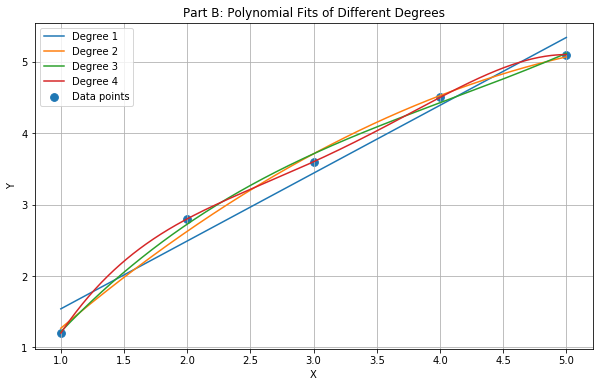


Part B Interpretation:
Degree 1 is the simplest model and may underfit if the data is not very linear.
As degree increases, MSE usually drops and R^2 usually increases on the training data.
With 5 data points, degree 4 can interpolate all points exactly, which is a sign of possible overfitting.
So for this dataset, low degree may underfit and the highest possible degree may overfit.
Best training fit in Part B by MSE: degree 4
Best degree 4 metrics: MSE = 0.000000, R^2 = 1.000000


In [10]:
# Part B: Increase and decrease polynomial degree

degrees_to_test = [1, 2, 3, 4]                         # Test several polynomial degrees
results_B = []                                         # Store the fit results for each degree

print("\nPart B: Polynomial Degree Study")
print("Degree-by-degree comparison:")

for deg in degrees_to_test:
    p = polynomial_fit(X, Y, deg)                      # Compute the polynomial fit of degree deg
    Yhat = p(X)                                        # Evaluate the fit at the original x points
    current_mse = mse(Y, Yhat)                         # Compute mean squared error
    current_r2 = r2_score(Y, Yhat)                     # Compute R^2
    results_B.append((deg, p, current_mse, current_r2))# Save this run's results
    print(f"Degree {deg}: MSE = {current_mse:.6f}, R^2 = {current_r2:.6f}")

plt.figure(figsize=(10, 6))                            # Create a figure for Part B
plt.scatter(X, Y, s=60, label="Data points")           # Plot the original data points

for deg, p, current_mse, current_r2 in results_B:
    y_plot = p(x_plot)                                 # Evaluate the polynomial on dense x values
    plt.plot(x_plot, y_plot, label=f"Degree {deg}")    # Plot that polynomial curve

plt.title("Part B: Polynomial Fits of Different Degrees")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()
plt.close()

print("\nPart B Interpretation:")
print("Degree 1 is the simplest model and may underfit if the data is not very linear.")
print("As degree increases, MSE usually drops and R^2 usually increases on the training data.")
print("With 5 data points, degree 4 can interpolate all points exactly, which is a sign of possible overfitting.")
print("So for this dataset, low degree may underfit and the highest possible degree may overfit.")

best_B = min(results_B, key=lambda item: item[2])      # Pick the model with the smallest MSE
best_degree, best_poly, best_mse, best_r2 = best_B

print(f"Best training fit in Part B by MSE: degree {best_degree}")
print(f"Best degree {best_degree} metrics: MSE = {best_mse:.6f}, R^2 = {best_r2:.6f}")


Part C: Vandermonde Matrix Polynomial Fit
Vandermonde cubic polynomial: y = 0.0417x^3 - 0.5107x^2 + 2.7476x - 1.0600
Vandermonde metrics: MSE = 0.004829, R^2 = 0.997413

Comparing Part A cubic fit to Part C Vandermonde cubic fit:
Part A cubic MSE = 0.004829, R^2 = 0.997413
Part C cubic MSE = 0.004829, R^2 = 0.997413
These should be the same or extremely close, because both methods solve the same cubic least-squares problem.


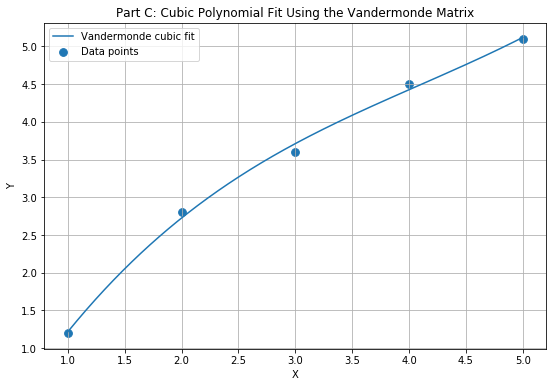


Final Summary
Part A compared a straight-line least-squares fit to a cubic polynomial fit.
Part B tested multiple polynomial degrees to show underfitting and overfitting behavior.
Part C rebuilt the cubic polynomial fit using the Vandermonde matrix and least squares.
MSE measures average squared error, so smaller is better.
R^2 measures how much variation is explained by the model, so larger is better.


In [11]:
# Part C: Vandermonde Matrix Polynomial Fit

degree_C = 3                                           # Use cubic again for comparison
poly_vander = vandermonde_fit(X, Y, degree_C)          # Compute cubic fit using the Vandermonde matrix
Yhat_vander = poly_vander(X)                           # Evaluate at the original x points
y_plot_vander = poly_vander(x_plot)                    # Evaluate on dense x values for plotting

mse_vander = mse(Y, Yhat_vander)                       # Mean squared error for Vandermonde cubic fit
r2_vander = r2_score(Y, Yhat_vander)                   # R^2 value for Vandermonde cubic fit

print("\nPart C: Vandermonde Matrix Polynomial Fit")
print(f"Vandermonde cubic polynomial: y = {poly_to_string(poly_vander)}")
print(f"Vandermonde metrics: MSE = {mse_vander:.6f}, R^2 = {r2_vander:.6f}")

print("\nComparing Part A cubic fit to Part C Vandermonde cubic fit:")
print(f"Part A cubic MSE = {mse_poly3:.6f}, R^2 = {r2_poly3:.6f}")
print(f"Part C cubic MSE = {mse_vander:.6f}, R^2 = {r2_vander:.6f}")
print("These should be the same or extremely close, because both methods solve the same cubic least-squares problem.")

plt.figure(figsize=(9, 6))                             # Create a figure for Part C
plt.scatter(X, Y, s=60, label="Data points")           # Plot the original data points
plt.plot(x_plot, y_plot_vander, label="Vandermonde cubic fit")   # Plot the Vandermonde cubic fit
plt.title("Part C: Cubic Polynomial Fit Using the Vandermonde Matrix")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()
plt.close()

# Final summary

print("\nFinal Summary")
print("Part A compared a straight-line least-squares fit to a cubic polynomial fit.")
print("Part B tested multiple polynomial degrees to show underfitting and overfitting behavior.")
print("Part C rebuilt the cubic polynomial fit using the Vandermonde matrix and least squares.")
print("MSE measures average squared error, so smaller is better.")
print("R^2 measures how much variation is explained by the model, so larger is better.")